# OU Process
Simulate a path with known parameters, fit on it, verify recovery.

In [17]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from spread.OU_process import OUProcess
from data.fetch import *


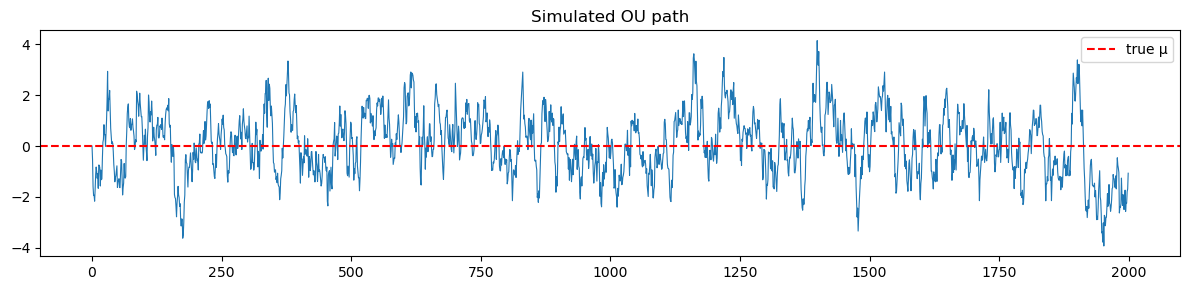

In [13]:
# True params
TRUE_KAPPA = 0.1
TRUE_MU    = 0.0
TRUE_SIGMA = 0.5
N_STEPS    = 2000
DT         = 1.0

ou = OUProcess()
ou.kappa = TRUE_KAPPA
ou.mu    = TRUE_MU
ou.sigma = TRUE_SIGMA

path = ou.simulate(n_steps=N_STEPS, dt=DT)

plt.figure(figsize=(12, 3))
plt.plot(path, linewidth=0.8)
plt.axhline(TRUE_MU, color='red', linestyle='--', label='true μ')
plt.title('Simulated OU path')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
ou_fitted = OUProcess()
ou_fitted.fit(path, dt=DT)

print(f"           True    Fitted")
print(f"kappa   {TRUE_KAPPA:.4f}   {ou_fitted.kappa:.4f}")
print(f"mu      {TRUE_MU:.4f}   {ou_fitted.mu:.4f}")
print(f"sigma   {TRUE_SIGMA:.4f}   {ou_fitted.sigma:.4f}")

           True    Fitted
kappa   0.1000   0.0926
mu      0.0000   0.0581
sigma   0.5000   0.5260


In [15]:
print(f"Half-life (fitted) : {ou_fitted.half_life():.2f} days")
print(f"Half-life (true)   : {np.log(2)/TRUE_KAPPA:.2f} days")
print(f"Eq. std   (fitted) : {ou_fitted.equilibrium_std():.4f}")
print(f"Eq. std   (true)   : {TRUE_SIGMA / np.sqrt(2*TRUE_KAPPA):.4f}")

Half-life (fitted) : 7.49 days
Half-life (true)   : 6.93 days
Eq. std   (fitted) : 1.2223
Eq. std   (true)   : 1.1180


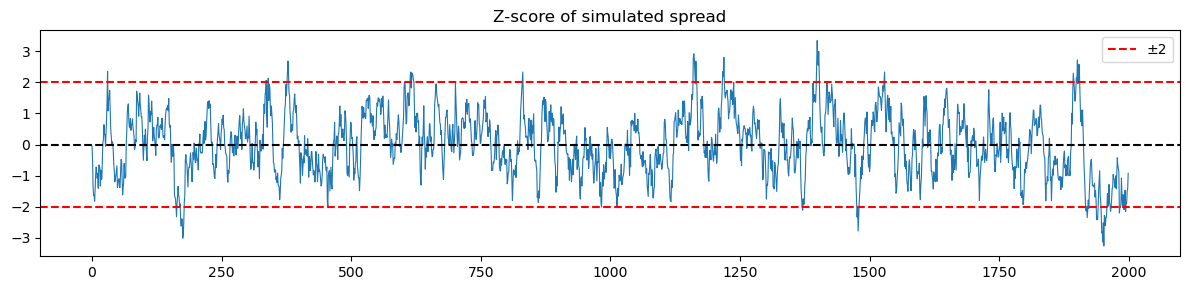

Z-score mean : 0.0045  (expected ~0)
Z-score std  : 0.9989  (expected ~1)


In [16]:
zscores = ou_fitted.zscore(path)

plt.figure(figsize=(12, 3))
plt.plot(zscores, linewidth=0.8)
plt.axhline(0,  color='black', linestyle='--')
plt.axhline(2,  color='red',   linestyle='--', label='±2')
plt.axhline(-2, color='red',   linestyle='--')
plt.title('Z-score of simulated spread')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Z-score mean : {zscores.mean():.4f}  (expected ~0)")
print(f"Z-score std  : {zscores.std():.4f}  (expected ~1)")

In [42]:
data = fetch_2tick('GLD', 'GDX', '2015-01-01', '2026-01-01')

[*********************100%***********************]  2 of 2 completed


In [43]:
spread = compute_pair_spread(data)

In [44]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=spread.index,
    y=spread.values,
    mode='lines',
    name='Spread',
    line=dict(color='#00b4d8', width=1)
))

fig.add_hline(y=spread.mean(), line_dash='dash', line_color='white', annotation_text='μ')

fig.update_layout(
    template='plotly_dark',
    title='GLD/GDX Spread',
    xaxis_title='Date',
    yaxis_title='Log Spread',
    height=400
)

fig.show()

In [45]:
# look a bit mean reverting .. negative mean just because of the relative price levels, nothing wrong there

In [46]:
# (spread.index[1]-spread.index[0]).days

In [47]:
ou_fitted = OUProcess()
ou_fitted.fit(spread)

print(f"kappa   {ou_fitted.kappa:.4f}")
print(f"mu      {ou_fitted.mu:.4f}")
print(f"sigma   {ou_fitted.sigma:.4f}")
print(f"Half-life (fitted) : {ou_fitted.half_life():.2f} days")


kappa   0.0097
mu      -2.3598
sigma   0.0012
Half-life (fitted) : 71.80 days


In [48]:
zscores = ou_fitted.zscore(spread.values)


In [49]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=spread.index, y=zscores,
    mode='lines', name='Z-score',
    line=dict(color='#00b4d8', width=1)
))

for level, label in [(2, '±2'), (-2, ''), (1, '±1'), (-1, '')]:
    fig.add_hline(y=level, line_dash='dash', line_color='rgba(255,100,100,0.5)',
                annotation_text=label)
fig.add_hline(y=0, line_color='white', line_dash='dot')

fig.update_layout(template='plotly_dark', title='GLD/GDX Z-score', height=400)
fig.show()